In [1]:
import os
import re
from sklearn import tree
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

pd.options.mode.chained_assignment

'warn'

In [2]:
df = pd.read_csv('/Users/ryan.oliveira/Desktop/puc/ppl-cd-pcd-sist-int-2025-1-grupo-5-2025-1/assets/data/State_of_data_BR_2023_original.csv')


In [3]:
colunas_codigo = ['P2_h', 'P4_d_1', 'P4_d_2', 'P4_d_3', 'P4_d_4', 'P4_d_5', 
                 'P4_d_6', 'P4_d_7', 'P4_d_8', 'P4_d_9', 'P4_d_10', 'P4_d_11', 
                 'P4_d_12', 'P4_d_13', 'P4_d_14', 'P4_d_15']

# Procurar strings que contêm os códigos desejados
colunas_selecionadas = []
for codigo in colunas_codigo:
    colunas_correspondentes = [col for col in df.columns if codigo in col]
    if colunas_correspondentes:
        colunas_selecionadas.extend(colunas_correspondentes)

# Criar o DataFrame com as colunas selecionadas
df_atributos_selecionados = df[colunas_selecionadas]

df_atributos_selecionados.columns

Index(['('P2_h ', 'Faixa salarial')', '('P4_d_1 ', 'SQL')',
       '('P4_d_10 ', 'Scala')', '('P4_d_11 ', 'Matlab')',
       '('P4_d_12 ', 'Rust')', '('P4_d_13 ', 'PHP')',
       '('P4_d_14 ', 'JavaScript')',
       '('P4_d_15 ', 'Não utilizo nenhuma linguagem')', '('P4_d_2 ', 'R ')',
       '('P4_d_3 ', 'Python')', '('P4_d_4 ', 'C/C++/C#')',
       '('P4_d_5 ', '.NET')', '('P4_d_6 ', 'Java')', '('P4_d_7 ', 'Julia')',
       '('P4_d_8 ', 'SAS/Stata')', '('P4_d_9 ', 'Visual Basic/VBA')',
       '('P4_d_10 ', 'Scala')', '('P4_d_11 ', 'Matlab')',
       '('P4_d_12 ', 'Rust')', '('P4_d_13 ', 'PHP')',
       '('P4_d_14 ', 'JavaScript')',
       '('P4_d_15 ', 'Não utilizo nenhuma linguagem')'],
      dtype='object')

In [16]:
df_novo = df_atributos_selecionados.copy()

df_novo.rename(
    columns={ 
        "('P2_h ', 'Faixa salarial')": "faixa_salarial",
        "('P4_d_1 ', 'SQL')": "sql",
        "('P4_d_2 ', 'R ')": "r",
        "('P4_d_3 ', 'Python')": "python",
        "('P4_d_4 ', 'C/C++/C#')": "c_cpp_csharp",
        "('P4_d_5 ', '.NET')": "dotnet",
        "('P4_d_6 ', 'Java')": "java",
        "('P4_d_7 ', 'Julia')": "julia",
        "('P4_d_8 ', 'SAS/Stata')": "sas_stata",
        "('P4_d_9 ', 'Visual Basic/VBA')": "vb_vba",
        "('P4_d_10 ', 'Scala')": "scala",
        "('P4_d_11 ', 'Matlab')": "matlab",
        "('P4_d_12 ', 'Rust')": "rust",
        "('P4_d_13 ', 'PHP')": "php",
        "('P4_d_14 ', 'JavaScript')": "javascript",
        "('P4_d_15 ', 'Não utilizo nenhuma linguagem')": "nao_utiliza_linguagem"
        },
    inplace=True
)

In [17]:
df_novo.columns

Index(['faixa_salarial', 'sql', 'scala', 'matlab', 'rust', 'php', 'javascript',
       'nao_utiliza_linguagem', 'r', 'python', 'c_cpp_csharp', 'dotnet',
       'java', 'julia', 'sas_stata', 'vb_vba', 'scala', 'matlab', 'rust',
       'php', 'javascript', 'nao_utiliza_linguagem'],
      dtype='object')

In [18]:
colunas_linguagem = ['sql', 'scala', 'matlab', 'rust', 'php', 'javascript', 'nao_utiliza_linguagem', 
           'r', 'python', 'c_cpp_csharp', 'dotnet', 'java', 'julia', 'sas_stata', 'vb_vba']

# Preencher NaN com 0 em cada coluna
for coluna in colunas_linguagem:
    if coluna in df_novo.columns:
        df_novo[coluna] = df_novo[coluna].fillna(0)

In [20]:
df_novo.columns

Index(['faixa_salarial', 'sql', 'scala', 'matlab', 'rust', 'php', 'javascript',
       'nao_utiliza_linguagem', 'r', 'python', 'c_cpp_csharp', 'dotnet',
       'java', 'julia', 'sas_stata', 'vb_vba', 'scala', 'matlab', 'rust',
       'php', 'javascript', 'nao_utiliza_linguagem'],
      dtype='object')

In [21]:
df_novo = df_novo.loc[:, ~df_novo.columns.duplicated()]

In [25]:
num_nulos = df_novo['faixa_salarial'].isnull().sum()
print(f"Número de valores nulos em 'faixa salarial': {num_nulos}")

Número de valores nulos em 'faixa salarial': 540


In [26]:
proporcao_nulos = num_nulos / len(df_novo)
print(f"Proporção de valores nulos: {proporcao_nulos:.2%}")

Proporção de valores nulos: 10.20%


In [27]:
nulos_df = df_novo[df_novo['faixa_salarial'].isnull()]
print(nulos_df.describe())

         sql  scala  matlab   rust    php  javascript  nao_utiliza_linguagem  \
count  540.0  540.0   540.0  540.0  540.0       540.0                  540.0   
mean     0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
std      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
min      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
25%      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
50%      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
75%      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
max      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   

           r  python  c_cpp_csharp  dotnet   java  julia  sas_stata  vb_vba  
count  540.0   540.0         540.0   540.0  540.0  540.0      540.0   540.0  
mean     0.0     0.0           0.0     0.0    0.0    0.0        0.0     0.0  
std      0.0     0.0           0.0     0.0   

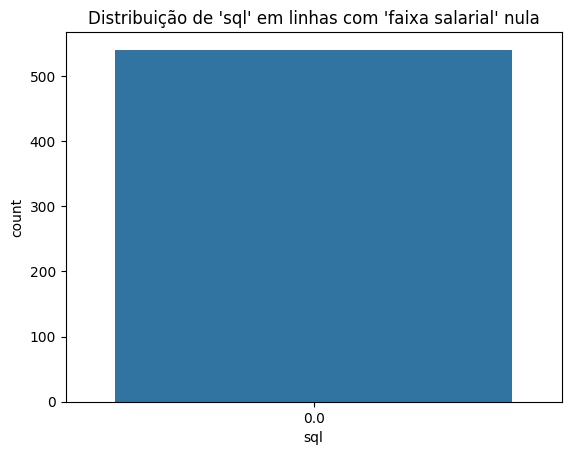

In [28]:
sns.countplot(data=nulos_df, x='sql')
plt.title("Distribuição de 'sql' em linhas com 'faixa salarial' nula")
plt.show()

In [29]:
nao_nulos_df = df_novo[df_novo['faixa_salarial'].notnull()]
print(nao_nulos_df.describe())

               sql        scala       matlab         rust          php  \
count  4753.000000  4753.000000  4753.000000  4753.000000  4753.000000   
mean      0.664002     0.027562     0.006312     0.001473     0.011782   
std       0.472388     0.163730     0.079204     0.038352     0.107915   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       1.000000     0.000000     0.000000     0.000000     0.000000   
75%       1.000000     0.000000     0.000000     0.000000     0.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

        javascript  nao_utiliza_linguagem            r       python  \
count  4753.000000            4753.000000  4753.000000  4753.000000   
mean      0.059331               0.064170     0.085841     0.594361   
std       0.236268               0.245081     0.280158     0.491067   
min       0.000000               0.000000     0.0

In [30]:
# Remover linhas onde 'faixa_salarial' é nula
df_novo = df_novo.dropna(subset=['faixa_salarial'])

In [32]:
df_novo.isna().sum()

faixa_salarial           0
sql                      0
scala                    0
matlab                   0
rust                     0
php                      0
javascript               0
nao_utiliza_linguagem    0
r                        0
python                   0
c_cpp_csharp             0
dotnet                   0
java                     0
julia                    0
sas_stata                0
vb_vba                   0
dtype: int64

In [38]:
unique_values = df_novo['faixa_salarial'].unique()
print(unique_values)

['de R$ 12.001/mês a R$ 16.000/mês' 'de R$ 6.001/mês a R$ 8.000/mês'
 'de R$ 4.001/mês a R$ 6.000/mês' 'de R$ 8.001/mês a R$ 12.000/mês'
 'de R$ 20.001/mês a R$ 25.000/mês' 'de R$ 1.001/mês a R$ 2.000/mês'
 'de R$ 3.001/mês a R$ 4.000/mês' 'de R$ 16.001/mês a R$ 20.000/mês'
 'de R$ 2.001/mês a R$ 3.000/mês' 'Acima de R$ 40.001/mês'
 'de R$ 25.001/mês a R$ 30.000/mês' 'Menos de R$ 1.000/mês'
 'de R$ 30.001/mês a R$ 40.000/mês' 'de R$ 101/mês a R$ 2.000/mês']


In [40]:
value_counts = df_novo['faixa_salarial'].value_counts()
print(value_counts)

faixa_salarial
de R$ 8.001/mês a R$ 12.000/mês     1026
de R$ 4.001/mês a R$ 6.000/mês       745
de R$ 12.001/mês a R$ 16.000/mês     650
de R$ 6.001/mês a R$ 8.000/mês       637
de R$ 3.001/mês a R$ 4.000/mês       352
de R$ 16.001/mês a R$ 20.000/mês     328
de R$ 2.001/mês a R$ 3.000/mês       288
de R$ 1.001/mês a R$ 2.000/mês       215
de R$ 20.001/mês a R$ 25.000/mês     195
de R$ 25.001/mês a R$ 30.000/mês     128
de R$ 30.001/mês a R$ 40.000/mês      86
Acima de R$ 40.001/mês                72
Menos de R$ 1.000/mês                 30
de R$ 101/mês a R$ 2.000/mês           1
Name: count, dtype: int64


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

y = df_novo['faixa_salarial']
X = df_novo.drop('faixa_salarial', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Fazer previsões no conjunto de treinamento
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Acurácia no conjunto de teste:", test_accuracy)
print("Acurácia no conjunto de treinamento:", train_accuracy)

Acurácia no conjunto de teste: 0.9852786540483701
Acurácia no conjunto de treinamento: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix

